# Подготовка территорий

Используем класс `LandDataPreparator`, чтобы собрать единый набор данных и сохранить результат.

### Входные данные

**scenario_blocks_path = "../data/prostor/scenario_blocks.pickle"** — GeoDataFrame сценарных участков. Обязательные атрибуты: геометрия `geometry` (проекция в метрах), доли типов использования (`residential`, `business`, `recreation`, `industrial`, `transport`, `special`, `agriculture`), агрегированные показатели `land_use`, `share`, `footprint_area`, `build_floor_area`, `living_area`, `non_living_area`.

**context_blocks_path = "../data/prostor/context_blocks.pickle"** — GeoDataFrame контекстных участков с идентичной структурой и той же CRS; используется для объединения с сценарными блоками.



In [1]:
import pandas as pd

scenario_blocks = pd.read_pickle('../data/scenario_blocks.pickle') #or scenario_198_blocks
context_blocks = pd.read_pickle('../data/context_blocks.pickle')


In [2]:
scenario_blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share
0,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180
1,"POLYGON ((388558.037 6645102.374, 388511.373 6...",0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081
2,"POLYGON ((387957.434 6643444.937, 388007.492 6...",0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381
3,"POLYGON ((388007.492 6643608.409, 387957.434 6...",0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862
4,"POLYGON ((388001.306 6643195.969, 388000.75 66...",0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN


In [3]:
context_blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,capacity_supermarket,count_supermarket,capacity_swimming_pool,count_swimming_pool,capacity_train_station,count_train_station,capacity_university,count_university,capacity_veterinary,count_veterinary
0,"POLYGON ((391549.648 6642620.924, 391440.516 6...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN,...,5000,1,1000,1,0,0,0,0,0,0
1,"POLYGON ((390728.805 6642824.074, 390766.253 6...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN,...,0,0,0,0,0,0,0,0,0,0
2,"POLYGON ((384619.942 6643780.507, 384592.897 6...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN,...,0,0,0,0,0,0,0,0,0,0
3,"POLYGON ((383701.245 6643709.235, 384459.417 6...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN,...,0,0,0,0,0,0,0,0,0,0
4,"POLYGON ((394792.785 6641449.688, 394618.737 6...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from urbanomy.methods.land_value_modeling.land_data_preparation import LandDataPreparator

preparator = LandDataPreparator(
    scenario_blocks_source=scenario_blocks,
    context_blocks_source=context_blocks,
    predict_project_only=False, 
)

prepared_blocks = preparator.prepare()
prepared_blocks.head()

/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
2025-11-28 12:08:17.936 | WARNING  | blocksnet.analysis.morphotypes.schemas:_before_validate:17 - Column l not found in columns. Calculating from fsi and gsi


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,is_project,geometry,id
0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180,6260.321243,...,202399.732193,0.062008,0.030930,0.000000,2.004756,low-rise non-residential,127.337432,True,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0
1,0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081,18143.767788,...,201529.493481,0.202340,0.090030,0.000000,2.247469,low-rise non-residential,125.993903,True,"POLYGON ((388558.037 6645102.374, 388511.373 6...",1
2,0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381,15011.641911,...,164663.859830,0.151737,0.091165,0.000000,1.664419,low-rise non-residential,123.419051,True,"POLYGON ((387957.434 6643444.937, 388007.492 6...",2
3,0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862,22467.055572,...,161571.832511,0.449142,0.139053,0.404539,3.230005,low-rise model,122.524407,True,"POLYGON ((388007.492 6643608.409, 387957.434 6...",3
4,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,0.316006,...,16.489152,0.079224,0.019164,0.000000,4.133916,mid-rise non-residential,122.658674,True,"POLYGON ((388001.306 6643195.969, 388000.75 66...",4


<Axes: >

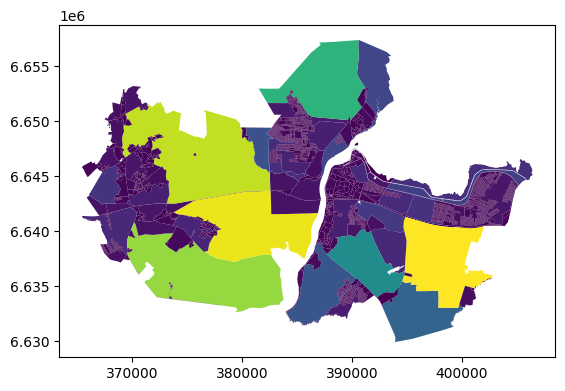

In [17]:
prepared_blocks.plot(column='footprint_area')

In [12]:
prepared_blocks.to_pickle("../data/prepared_blocks.pickle")
